<a href="https://colab.research.google.com/github/D2718281828nis/Fuzzy-fundamentals/blob/main/example-Fuzzy-Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Примеры графов

In [1]:
import networkx as nx
from networkx.algorithms.community import modularity

# 1. Создаем наш граф из 4 вершин и 2 изолированных ребер
G = nx.Graph()
G.add_edges_from([(1, 2), (3, 4)])

# Задаем идеальное разбиение на сообщества: {1, 2} и {3, 4}
ideal_communities = [{1, 2}, {3, 4}]

# Считаем модулярность для идеального разбиения
q_ideal = modularity(G, ideal_communities)
print(f"Модулярность идеального разбиения: {q_ideal}") # Выведет 0.5


# 2. Теперь добавим связь между сообществами (ребро 2-3)
G.add_edge(2, 3)

# Считаем модулярность для тех же групп, но уже в более связном графе
q_with_bridge = modularity(G, ideal_communities)
print(f"Модулярность после добавления моста (2-3): {q_with_bridge:.3f}") # Выведет 0.222


# 3. А что если мы разобьем граф неправильно?
# Например, объединим {1, 3} и {2, 4}
bad_communities = [{1, 3}, {2, 4}]
q_bad = modularity(G, bad_communities)
print(f"Модулярность плохого разбиения: {q_bad:.3f}") # Выведет -0.389


Модулярность идеального разбиения: 0.5
Модулярность после добавления моста (2-3): 0.167
Модулярность плохого разбиения: -0.500


In [2]:
import networkx.algorithms.community as nx_comm

# 1. Создаем тестовый граф (например, граф «Карате-клуб Закари» — классический пример для поиска сообществ)
G = nx.karate_club_graph()

# 2. Запускаем алгоритм Лувена
# Он автоматически найдет оптимальное разбиение, максимизируя Q
communities = nx_comm.louvain_communities(G, seed=42)

# 3. Считаем итоговую модулярность полученного разбиения
q_value = nx_comm.modularity(G, communities)

print(f"Алгоритм нашел сообществ: {len(communities)}")
print(f"Максимальная модулярность Q: {q_value:.3f}")

# Выведем состав сообществ
for i, com in enumerate(communities):
    print(f"Сообщество {i+1}: {sorted(list(com))}")


Алгоритм нашел сообществ: 4
Максимальная модулярность Q: 0.427
Сообщество 1: [1, 2, 3, 7, 12, 13]
Сообщество 2: [0, 4, 5, 6, 10, 11, 16, 17, 19, 21]
Сообщество 3: [24, 25, 28, 31]
Сообщество 4: [8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]


In [4]:
!pip install -q cdlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.3/314.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 68.9 MB/s eta 0:00:00


# Нечеткая модулярность

--- Часть 1: Классическая модулярность ---
Модулярность идеального разбиения: 0.5
Модулярность после добавления моста (2-3): 0.167
Модулярность плохого разбиения: -0.500

--- Часть 2: Визуализация четкого разбиения (Карате-клуб Закари) ---
Алгоритм Лувена нашел сообществ: 4
Максимальная модулярность Q: 0.427


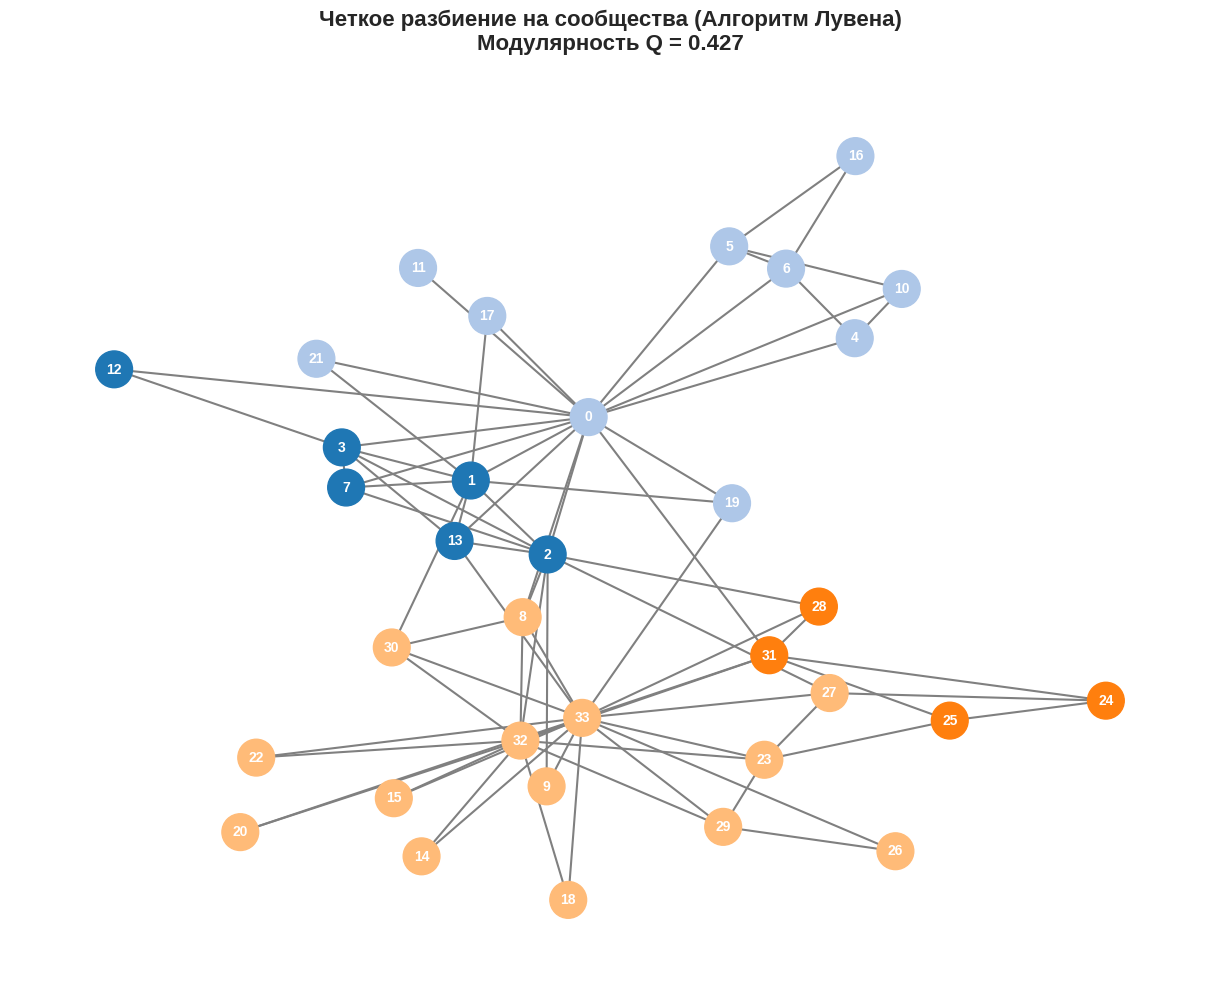


--- Часть 3: Нечеткая (перекрывающаяся) модулярность ---
Алгоритм DEMON нашел перекрывающихся сообществ: 3
Нечеткая модулярность (Overlapping Modularity): 0.315

Найдено узлов, принадлежащих нескольким сообществам одновременно: 6
Примеры перекрывающихся узлов (Узел -> [Индексы сообществ]):
  Узел 2: сообщества [0, 1]
  Узел 8: сообщества [0, 1]
  Узел 30: сообщества [0, 1]
  Узел 32: сообщества [0, 1]
  Узел 33: сообщества [0, 1]

--- Часть 4: Визуализация перекрывающихся сообществ ---


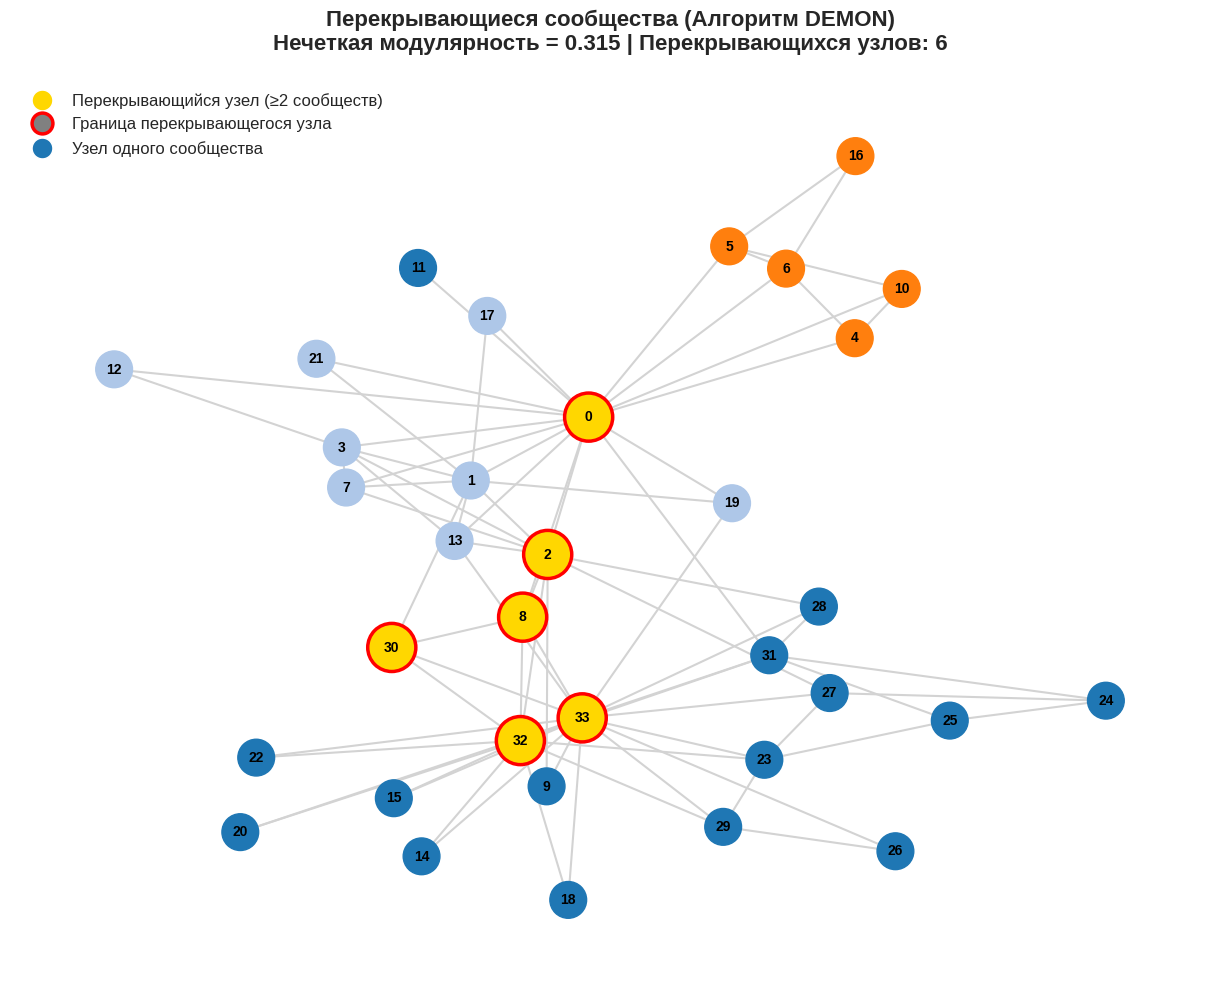

In [8]:
# =============================================================================
# Установка зависимостей (раскомментируйте для запуска в Google Colab)
# =============================================================================
# !pip install -q networkx matplotlib cdlib

import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import modularity
import networkx.algorithms.community as nx_comm
import warnings
import sys
import os

# Подавляем предупреждения cdlib об опциональных зависимостях для чистоты вывода
warnings.filterwarnings("ignore", message="to be able to use all crisp methods")

# Настройка стиля визуализации для высокого качества
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

# =============================================================================
# Часть 1: Классическая (четкая) модулярность на простом графе
# =============================================================================
print("--- Часть 1: Классическая модулярность ---")

G_simple = nx.Graph()
G_simple.add_edges_from([(1, 2), (3, 4)])
ideal_communities = [{1, 2}, {3, 4}]

q_ideal = modularity(G_simple, ideal_communities)
print(f"Модулярность идеального разбиения: {q_ideal}")

G_simple.add_edge(2, 3)
q_with_bridge = modularity(G_simple, ideal_communities)
print(f"Модулярность после добавления моста (2-3): {q_with_bridge:.3f}")

bad_communities = [{1, 3}, {2, 4}]
q_bad = modularity(G_simple, bad_communities)
print(f"Модулярность плохого разбиения: {q_bad:.3f}\n")


# =============================================================================
# Часть 2: Визуализация четкого разбиения (Алгоритм Лувена)
# =============================================================================
print("--- Часть 2: Визуализация четкого разбиения (Карате-клуб Закари) ---")

G_karate = nx.karate_club_graph()
crisp_communities = nx_comm.louvain_communities(G_karate, seed=42)
q_crisp = nx_comm.modularity(G_karate, crisp_communities)

print(f"Алгоритм Лувена нашел сообществ: {len(crisp_communities)}")
print(f"Максимальная модулярность Q: {q_crisp:.3f}")

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G_karate, seed=42, k=0.3)
color_palette = plt.cm.tab20.colors

node_colors = []
for node in G_karate.nodes():
    comm_idx = next(i for i, com in enumerate(crisp_communities) if node in com)
    node_colors.append(color_palette[comm_idx % len(color_palette)])

nx.draw(G_karate, pos,
        with_labels=True,
        node_color=node_colors,
        node_size=700,
        font_size=10,
        font_weight='bold',
        font_color='white',
        edge_color='gray',
        width=1.5)

plt.title(f"Четкое разбиение на сообщества (Алгоритм Лувена)\nМодулярность Q = {q_crisp:.3f}",
          fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()


# =============================================================================
# Часть 3: Нечеткая (перекрывающаяся) модулярность с использованием CDlib
# =============================================================================
print("\n--- Часть 3: Нечеткая (перекрывающаяся) модулярность ---")

try:
    # Перенаправляем stdout на короткое время, чтобы скрыть оставшиеся print-предупреждения cdlib
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')
    from cdlib import algorithms
    sys.stdout = old_stdout

    # Алгоритм DEMON для обнаружения перекрывающихся сообществ.
    # epsilon=0.25 - баланс между количеством и размером сообществ.
    fuzzy_communities = algorithms.demon(G_karate, epsilon=0.5, min_com_size=3)

    # Оценка нечеткой модулярности (Overlapping Modularity)
    fuzzy_mod_result = fuzzy_communities.modularity_overlap()

    print(f"Алгоритм DEMON нашел перекрывающихся сообществ: {len(fuzzy_communities.communities)}")
    print(f"Нечеткая модулярность (Overlapping Modularity): {fuzzy_mod_result.score:.3f}")

    # Анализ пересечений
    node_membership = fuzzy_communities.to_node_community_map()
    overlapping_nodes = {node: coms for node, coms in node_membership.items() if len(coms) > 1}

    print(f"\nНайдено узлов, принадлежащих нескольким сообществам одновременно: {len(overlapping_nodes)}")

    if overlapping_nodes:
        print("Примеры перекрывающихся узлов (Узел -> [Индексы сообществ]):")
        for node, coms in list(overlapping_nodes.items())[:5]:
            print(f"  Узел {node}: сообщества {coms}")

    # =============================================================================
    # Часть 4: Визуализация перекрывающихся сообществ
    # =============================================================================
    print("\n--- Часть 4: Визуализация перекрывающихся сообществ ---")

    plt.figure(figsize=(12, 9))

    # Для визуализации перекрывающихся сообществ мы назначим узлу цвет "основного"
    # (первого) сообщества, но выделим перекрывающиеся узлы визуально.
    node_colors = []
    node_sizes = []
    edge_colors = []

    # Создаем карту: узел -> список индексов сообществ
    node_to_comms = fuzzy_communities.to_node_community_map()

    for node in G_karate.nodes():
        comms = node_to_comms.get(node, [])
        if len(comms) > 1:
            # Перекрывающийся узел: выделяем размером и специальным цветом (например, светло-желтый)
            node_colors.append('#FFD700') # Gold
            node_sizes.append(1200)
        else:
            # Обычный узел: цвет по его единственному сообществу
            comm_idx = comms[0] if comms else 0
            node_colors.append(color_palette[comm_idx % len(color_palette)])
            node_sizes.append(700)

    nx.draw(G_karate, pos,
            with_labels=True,
            node_color=node_colors,
            node_size=node_sizes,
            font_size=10,
            font_weight='bold',
            font_color='black',
            edge_color='lightgray',
            width=1.5)

    # Дополнительно рисуем красную обводку для перекрывающихся узлов
    overlapping_node_list = list(overlapping_nodes.keys())
    if overlapping_node_list:
        nx.draw_networkx_nodes(G_karate, pos,
                               nodelist=overlapping_node_list,
                               node_size=1200,
                               node_color='none',
                               edgecolors='red',
                               linewidths=2.5)

    # Добавляем легенду
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFD700', markersize=15, label='Перекрывающийся узел (≥2 сообществ)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=15, markeredgecolor='red', markeredgewidth=2.5, label='Граница перекрывающегося узла'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_palette[0], markersize=15, label='Узел одного сообщества')
    ]
    plt.legend(handles=legend_elements, loc='upper left', fontsize=12, framealpha=0.9)

    plt.title(f"Перекрывающиеся сообщества (Алгоритм DEMON)\nНечеткая модулярность = {fuzzy_mod_result.score:.3f} | Перекрывающихся узлов: {len(overlapping_nodes)}",
              fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("Ошибка: Библиотека cdlib не установлена.")
    print("Для оценки нечеткой модулярности выполните в ячейке: !pip install cdlib")
except Exception as e:
    print(f"Произошла ошибка при выполнении нечеткого анализа: {e}")